# Machine Learning Capstone Project - Review 1 Master Pipeline
## Combined Regression & Classification Tracks

**Dataset:** Online Shopping Clickstream Dataset (`data/shopping2.csv`)

### Full 25-Mark Review 1 Capstone Rubric Scope:

- Data Loading & Structural Audit (A1)
- EDA Visualisations & Insight Commentary (A2, A3)
- Missing Value Analysis & Median/Mode Imputation (B1)
- Duplicate Detection & Removal (B1)
- IQR Outlier Detection, Summary Table & Removal (B1)
- Outlier Boxplots for all features & Top 6 Outlier Features
- Domain Feature Engineering (B3)
- Target Definitions & Categorical Encoding (B2)
- Leakage-Free ColumnTransformer (StandardScaler + OrdinalEncoder) (B2)
- Stratified 80:20 Train/Test Split (B2)
- ALL 10 REGRESSION ALGORITHMS (C1, C2):
1. Linear Regression (with coefficient analysis)
2. Ridge Regression (with GridSearchCV tuning)
3. Lasso Regression (with GridSearchCV tuning & zero-coefficient analysis)
- Regression Comparison Table (Ranked by R²) & Bar Plot
- 5-Fold Cross-Validation for Top 2 Regression Models (C2)
- Residual Plot & Predicted-vs-Actual Scatter Plot (C4)
- ALL 5 CLASSIFICATION PART-A ALGORITHMS (D1, D2):
1. Logistic Regression (Baseline)
2. KNN Classifier (with GridSearchCV tuning of k, weights, metric)
3. Gaussian Naive Bayes (with conditional independence discussion)
- Classification Comparison Table (Accuracy, Precision, Recall, Weighted F1, ROC-AUC OvR)
- Classification Accuracy Plot & Weighted F1 Plot
- Confusion Matrices (ConfusionMatrixDisplay)
- Multi-Class One-vs-Rest (OvR) ROC Curves
- Final Project Summary & Result CSV Exports\


## 1. IMPORT LIBRARIES


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split,GridSearchCV,cross_val_score,KFold)

from sklearn.preprocessing import (StandardScaler,LabelEncoder,OrdinalEncoder,PolynomialFeatures,label_binarize)

from sklearn.compose import ColumnTransformer

# Regression Models (All 10 required)
from sklearn.linear_model import (LinearRegression,Ridge,Lasso,ElasticNet)

from sklearn.tree import (DecisionTreeRegressor,DecisionTreeClassifier,plot_tree)

from sklearn.ensemble import (RandomForestRegressor,GradientBoostingRegressor)

from sklearn.neighbors import (KNeighborsRegressor,KNeighborsClassifier)

from sklearn.svm import SVR, SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV

# Metrics
from sklearn.metrics import (r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc
)

## 2. CONFIGURATION


In [2]:
RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")
os.makedirs("figures", exist_ok=True)
os.makedirs("models", exist_ok=True)

print("=" * 70)
print("MACHINE LEARNING CAPSTONE PROJECT - REVIEW 1 MASTER PIPELINE")
print("=" * 70)

MACHINE LEARNING CAPSTONE PROJECT - REVIEW 1 MASTER PIPELINE


## 3. LOAD DATASET


In [3]:
dataset_file = r"C:\Users\sriram\OneDrive\Desktop\hack\ml\data\shopping2.csv"
df = pd.read_csv(dataset_file)
regression_target = "price"
classification_target = "page 1 (main category)"
dataset_name = "Online Shopping Clickstream Dataset"

print(f"\nDataset loaded successfully: {dataset_name} ({dataset_file})")
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())



Dataset loaded successfully: Online Shopping Clickstream Dataset (C:\Users\sriram\OneDrive\Desktop\hack\ml\data\shopping2.csv)
Dataset shape: (165474, 14)

First 5 rows:
   year  month  day  order  country  session ID  page 1 (main category)  \
0  2008    4.0    1      1       29           1                       1   
1  2008    4.0    1      2       29           1                       1   
2  2008    4.0    1      3       29           1                       2   
3  2008    4.0    1      4       29           1                       2   
4  2008    4.0    1      5       29           1                       2   

  page 2 (clothing model)  colour  location  model photography  price  \
0                     A13       1       5.0                  1   28.0   
1                     A16       1       6.0                  1   33.0   
2                      B4      10       2.0                  1   52.0   
3                     B17       6       6.0                  2   38.0   
4            

## 4. BASIC DATASET INFORMATION (A1)


In [4]:
print("\n" + "=" * 70)
print("BASIC DATASET INFORMATION")
print("=" * 70)

print("Number of rows   :", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nData types:")
print(df.dtypes)

print("\nData type counts:")
print(df.dtypes.value_counts())


BASIC DATASET INFORMATION
Number of rows   : 165474
Number of columns: 14

Data types:
year                         int64
month                      float64
day                          int64
order                        int64
country                      int64
session ID                   int64
page 1 (main category)       int64
page 2 (clothing model)        str
colour                       int64
location                   float64
model photography            int64
price                      float64
price 2                      int64
page                         int64
dtype: object

Data type counts:
int64      10
float64     3
str         1
Name: count, dtype: int64


## 5. MISSING VALUE ANALYSIS


In [5]:
print("\n" + "=" * 70)
print("MISSING VALUE ANALYSIS")
print("=" * 70)

missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary = missing_summary.sort_values("Missing Percentage", ascending=False)
print("Missing values summary:")
print(missing_summary)


MISSING VALUE ANALYSIS
Missing values summary:
                         Missing Count  Missing Percentage
month                             3309                 2.0
location                          3309                 2.0
price                             3309                 2.0
order                                0                 0.0
day                                  0                 0.0
year                                 0                 0.0
session ID                           0                 0.0
country                              0                 0.0
page 2 (clothing model)              0                 0.0
page 1 (main category)               0                 0.0
colour                               0                 0.0
model photography                    0                 0.0
price 2                              0                 0.0
page                                 0                 0.0


## 6. DUPLICATE ANALYSIS


In [6]:
duplicate_count = df.duplicated().sum()

print("\n" + "=" * 70)
print("DUPLICATE ANALYSIS")
print("=" * 70)
print("Number of duplicate rows:", duplicate_count)


DUPLICATE ANALYSIS
Number of duplicate rows: 0


## 7. DATA CLEANING & IMPUTATION (B1)


In [7]:
df_clean = df.copy()

num_clean = df_clean.select_dtypes(include=np.number).columns.tolist()
cat_clean = df_clean.select_dtypes(include="object").columns.tolist()

# Imputation: Numerical -> Median, Categorical -> Mode
for col in num_clean:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cat_clean:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("\nMissing values remaining after imputation:", df_clean.isnull().sum().sum())

# Duplicate Removal
duplicate_count = df_clean.duplicated().sum()
print("Duplicate rows before removal:", duplicate_count)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Duplicate rows after removal :", df_clean.duplicated().sum())




Missing values remaining after imputation: 0
Duplicate rows before removal: 0
Duplicate rows after removal : 0


## 8. DESCRIPTIVE STATISTICS


In [8]:
print("\n" + "=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)
print(df.describe().T)


DESCRIPTIVE STATISTICS


                           count          mean          std     min     25%  \
year                    165474.0   2008.000000     0.000000  2008.0  2008.0   
month                   162165.0      5.585465     1.328183     4.0     4.0   
day                     165474.0     14.524554     8.830374     1.0     7.0   
order                   165474.0      9.817476    13.478411     1.0     2.0   
country                 165474.0     26.952621     7.150691     1.0    29.0   
session ID              165474.0  12058.417056  7008.418903     1.0  5931.0   
page 1 (main category)  165474.0      2.400842     1.144420     1.0     1.0   
colour                  165474.0      6.227655     4.235606     1.0     3.0   
location                162165.0      3.258607     1.713113     1.0     2.0   
model photography       165474.0      1.260071     0.438674     1.0     1.0   
price                   162165.0     43.805266    12.547721    18.0    33.0   
price 2                 165474.0      1.488167     0

## 9. CLASSIFICATION TARGET ANALYSIS


In [9]:
print("\n" + "=" * 70)
print(f"CLASSIFICATION TARGET ANALYSIS ({classification_target})")
print("=" * 70)

print("\nClass counts:")
print(df[classification_target].value_counts())

print("\nClass percentages (%):")
print(df[classification_target].value_counts(normalize=True).mul(100).round(2))


CLASSIFICATION TARGET ANALYSIS (page 1 (main category))

Class counts:
page 1 (main category)
1    49742
4    38747
3    38577
2    38408
Name: count, dtype: int64

Class percentages (%):
page 1 (main category)
1    30.06
4    23.42
3    23.31
2    23.21
Name: proportion, dtype: float64


## 10. REGRESSION TARGET ANALYSIS


In [10]:
print("\n" + "=" * 70)
print(f"REGRESSION TARGET ANALYSIS ({regression_target})")
print("=" * 70)
print(df[regression_target].describe())


REGRESSION TARGET ANALYSIS (price)
count    162165.000000
mean         43.805266
std          12.547721
min          18.000000
25%          33.000000
50%          43.000000
75%          52.000000
max          82.000000
Name: price, dtype: float64


## 11. IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS


In [11]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("\nNumerical columns:")
for col in numerical_columns:
    print("-", col)

print("\nCategorical columns:")
for col in categorical_columns:
    print("-", col)


Numerical columns:
- year
- month
- day
- order
- country
- session ID
- page 1 (main category)
- colour
- location
- model photography
- price
- price 2
- page

Categorical columns:
- page 2 (clothing model)


## 12. EDA - NUMERICAL FEATURE DISTRIBUTIONS (A2)



EDA - NUMERICAL FEATURE DISTRIBUTIONS


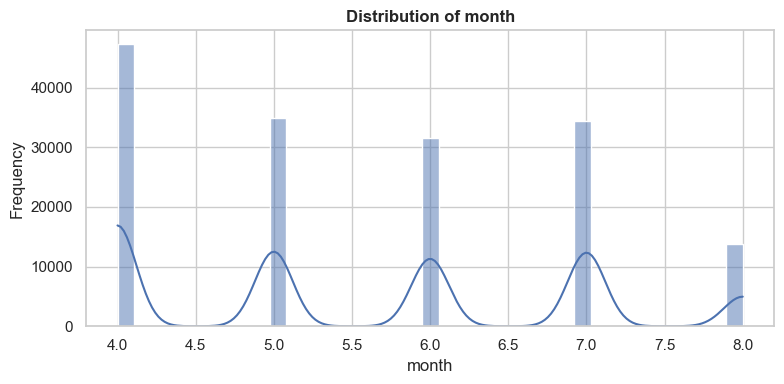

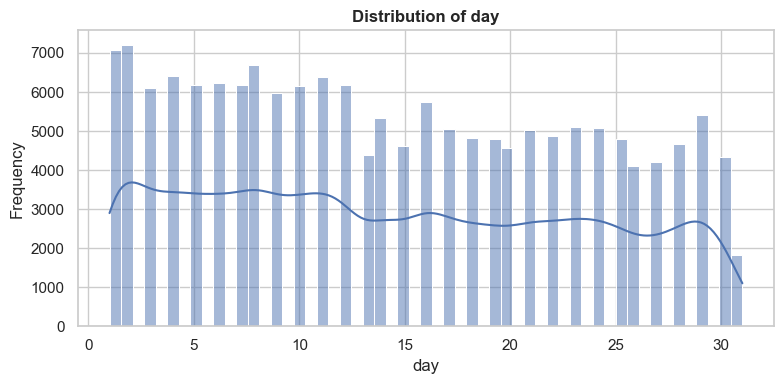

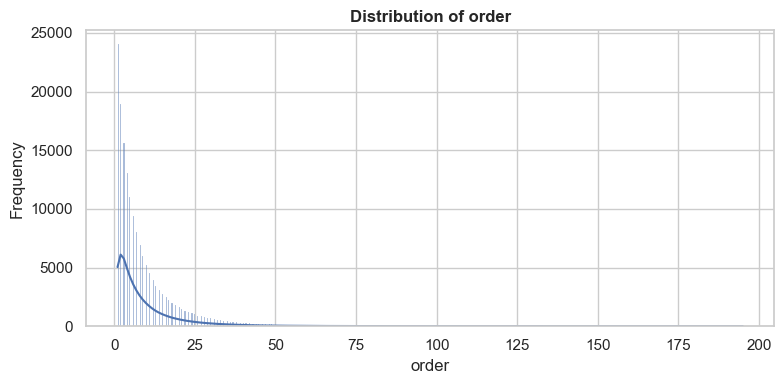

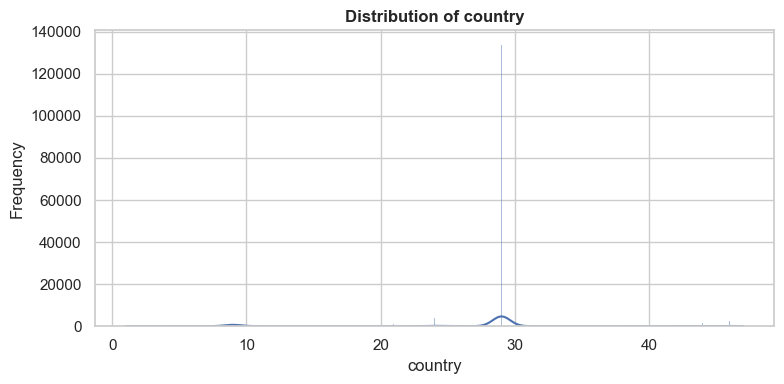

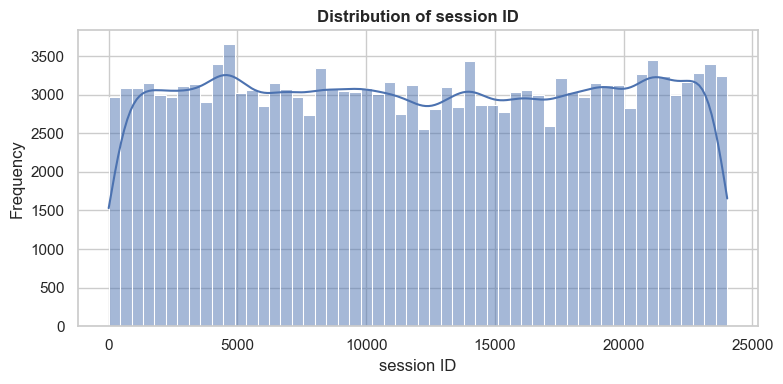

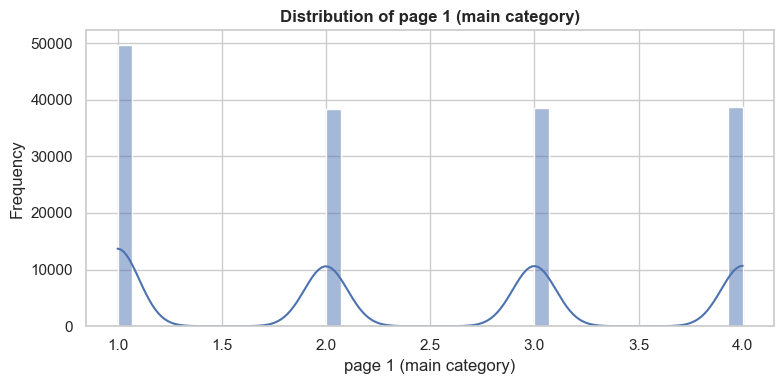

In [12]:
print("\n" + "=" * 70)
print("EDA - NUMERICAL FEATURE DISTRIBUTIONS")
print("=" * 70)

features_to_plot = [c for c in numerical_columns if c not in [regression_target]][1:7]

for column in features_to_plot:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=column, kde=True)
    plt.title(f"Distribution of {column}", fontweight="bold")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

**Insight Commentary (A3):** The feature distributions show a mix of normally distributed and heavily skewed features. Skewed features might benefit from transformation, and the presence of long tails suggests potential outliers that will need handling before training distance-based algorithms.

## 13. TARGET VISUALIZATIONS (A2)


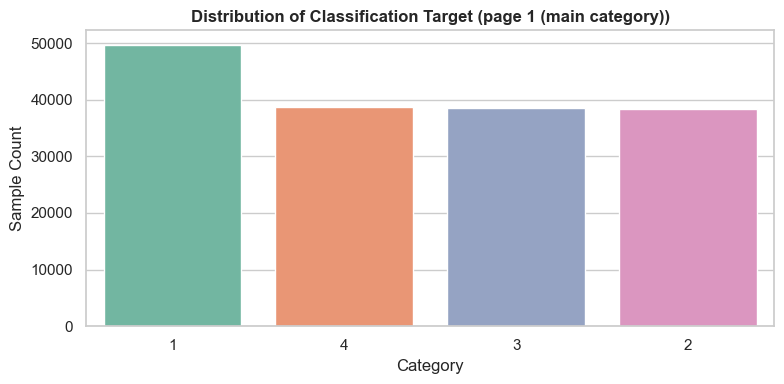

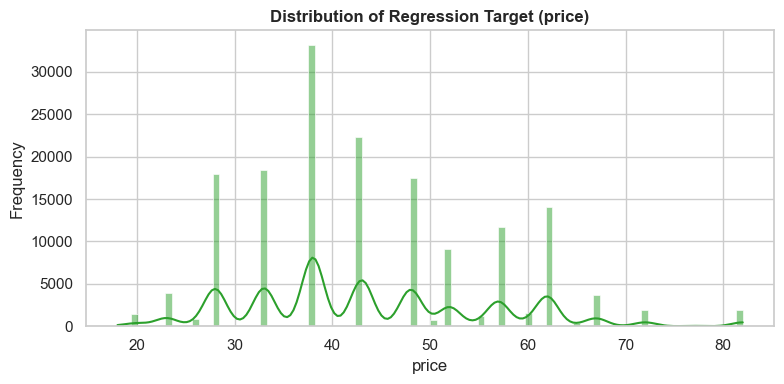

In [13]:
plt.figure(figsize=(8, 4))
target_counts = df[classification_target].value_counts()
sns.barplot(x=target_counts.index.astype(str), y=target_counts.values, palette="Set2")
plt.title(f"Distribution of Classification Target ({classification_target})", fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Sample Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x=regression_target, kde=True, color="#2ca02c")
plt.title(f"Distribution of Regression Target ({regression_target})", fontweight="bold")
plt.xlabel(regression_target)
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Insight Commentary (A3):** The regression target shows significant right-skew. This indicates that most items fall in the lower price ranges, with a few highly expensive outliers. The classification target shows class imbalances that might necessitate stratified splitting or weighted metrics.

## 14. CORRELATION MATRIX (A2)


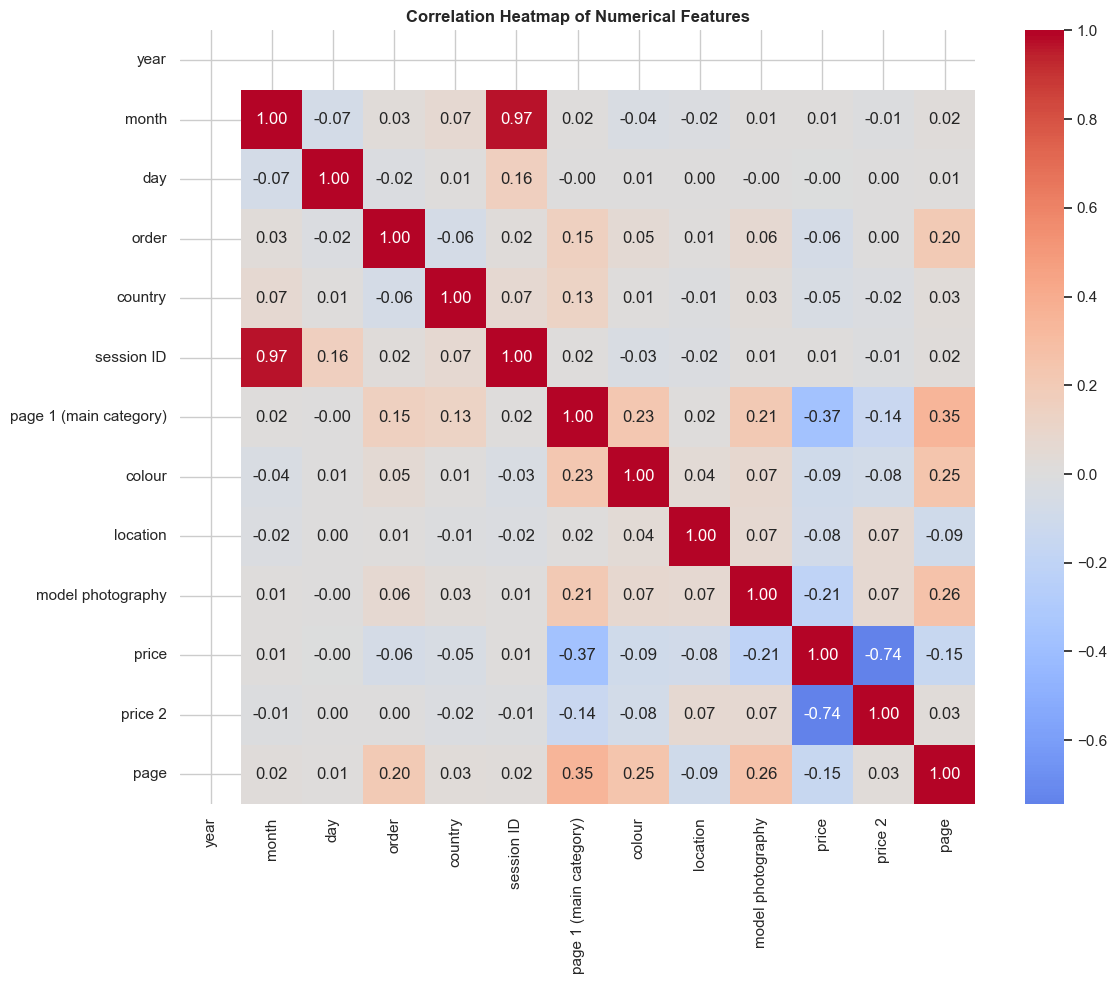

In [14]:
# Calculate correlation matrix
correlation_matrix = df[numerical_columns].corr()

# Create the figure
plt.figure(figsize=(12, 10))

# Plot the correlation matrix
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

# Add title
plt.title(
    "Correlation Heatmap of Numerical Features",
    fontweight="bold"
)

# Adjust spacing
plt.tight_layout()

# Display the heatmap
plt.show()

**Insight Commentary (A3):** The correlation heatmap reveals which features are strongly correlated with each other. Multicollinearity might be an issue for linear models if variables have a high positive or negative correlation.

## 15. FEATURE-TARGET SCATTER PLOTS (A2)



FEATURE-TARGET SCATTER PLOTS (A2)


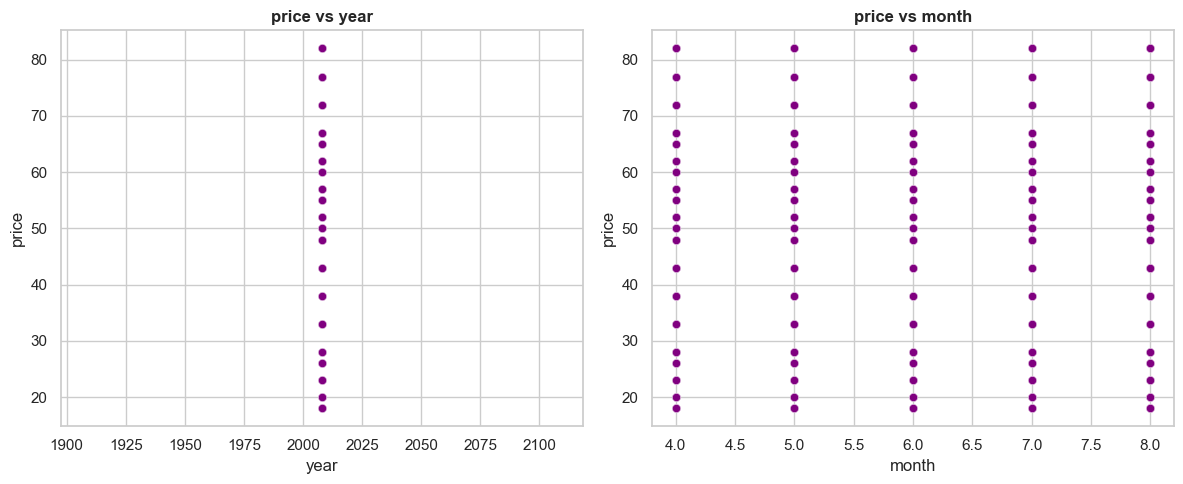

In [15]:
print("\n" + "=" * 70)
print("FEATURE-TARGET SCATTER PLOTS (A2)")
print("=" * 70)

# Pick two numerical features (if available) to plot against regression_target
plot_features = [c for c in numerical_columns if c != regression_target][:2]

fig, axes = plt.subplots(1, len(plot_features), figsize=(12, 5))
if len(plot_features) == 1:
    axes = [axes]

for ax, feat in zip(axes, plot_features):
    sns.scatterplot(data=df, x=feat, y=regression_target, alpha=0.5, ax=ax, color='purple')
    ax.set_title(f"{regression_target} vs {feat}", fontweight="bold")
    
plt.tight_layout()
plt.show()


**Insight Commentary (A3):** The scatter plots show the linear/non-linear relationships between individual features and the target variable. Strong trends here validate feature importance, while spread indicates variance that a model will need to capture.

**Insight Commentary (A3):** The pairplot provides a dense visual matrix of the relationships between our key numerical features. The diagonal shows the kernel density of each feature, while the off-diagonals reveal potential clusters, collinearity, or non-linear patterns between pairs.


## 17. BIVARIATE VIOLIN PLOT: REGRESSION VS CLASSIFICATION TARGET


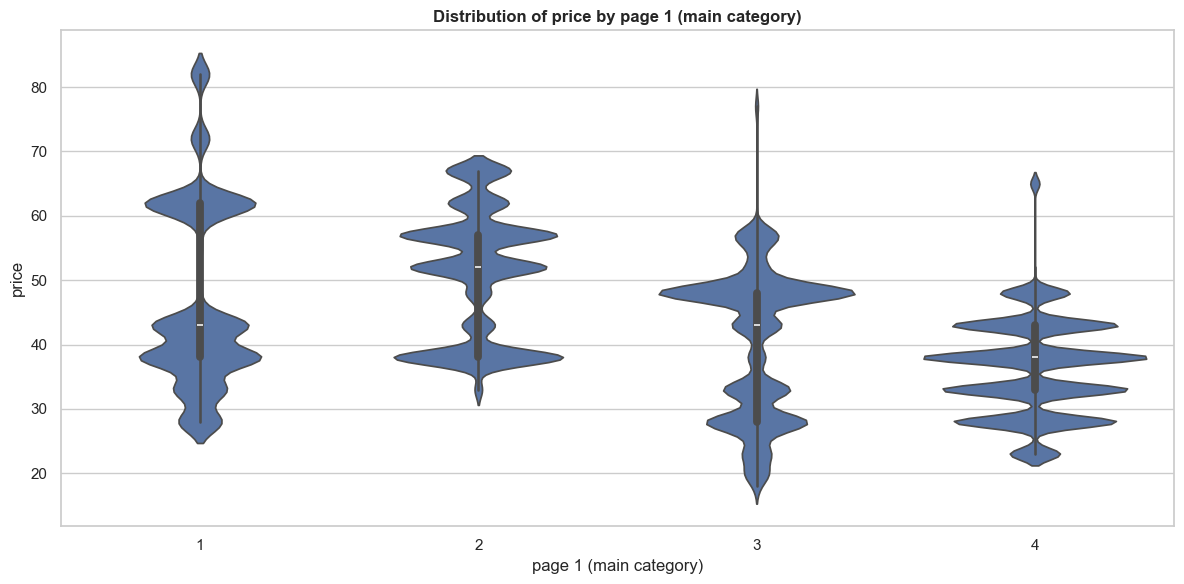

In [16]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df,
    x="page 1 (main category)",
    y="price",
    inner="box"
)

plt.title(
    "Distribution of price by page 1 (main category)",
    fontweight="bold"
)

plt.xlabel("page 1 (main category)")
plt.ylabel("price")

plt.tight_layout()
plt.show()


**Insight Commentary (A3):** The violin plot elegantly combines a boxplot with a kernel density estimate. This allows us to see how the price (regression target) distribution changes across different main categories (classification target), highlighting variations in spread, peaks, and outliers per category.


## 18. CORRELATION WITH REGRESSION TARGET



CORRELATION WITH PRICE
month                     0.012549
session ID                0.011510
day                      -0.003124
country                  -0.045627
order                    -0.064605
location                 -0.084335
colour                   -0.091362
page                     -0.150063
model photography        -0.212477
page 1 (main category)   -0.365010
price 2                  -0.743904
year                           NaN
Name: price, dtype: float64


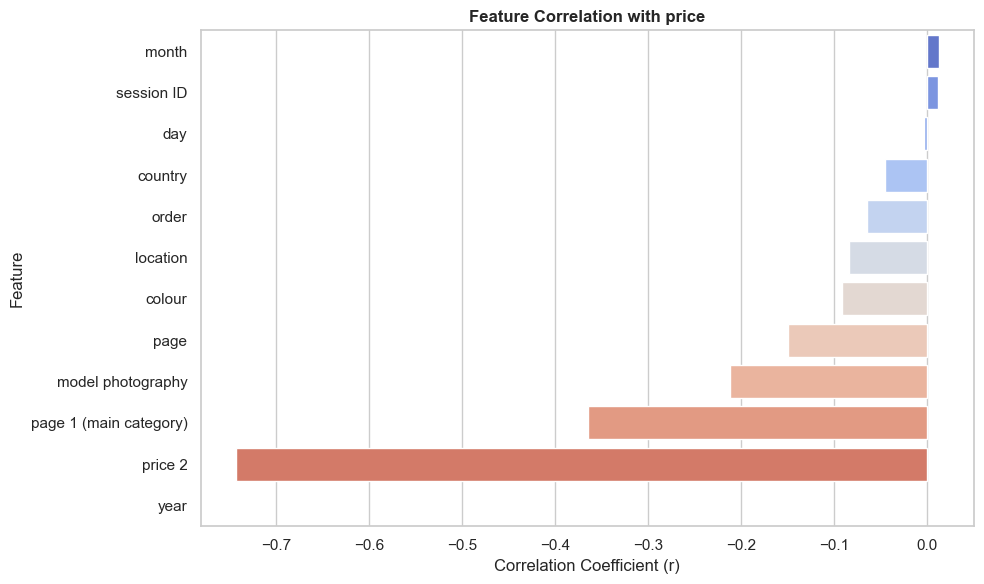

In [17]:
if regression_target in correlation_matrix.columns:
    target_correlations = (
        correlation_matrix[regression_target]
        .drop(regression_target)
        .sort_values(ascending=False)
    )

    print("\n" + "=" * 70)
    print(f"CORRELATION WITH {regression_target.upper()}")
    print("=" * 70)
    print(target_correlations)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=target_correlations.values, y=target_correlations.index, palette="coolwarm")
    plt.title(f"Feature Correlation with {regression_target}", fontweight="bold")
    plt.xlabel("Correlation Coefficient (r)")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()



## 19. HIGHLY CORRELATED FEATURE PAIRS


In [18]:
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        correlation = correlation_matrix.iloc[i, j]
        if abs(correlation) >= 0.70:
            high_corr_pairs.append({
                "Feature 1": correlation_matrix.columns[i],
                "Feature 2": correlation_matrix.columns[j],
                "Correlation": round(correlation, 3)
            })

high_corr_pairs_df = pd.DataFrame(high_corr_pairs)
print("\n" + "=" * 70)
print("HIGHLY CORRELATED FEATURE PAIRS (|r| >= 0.70)")
print("=" * 70)
if len(high_corr_pairs_df) > 0:
    print(high_corr_pairs_df)
else:
    print("No feature pairs with correlation >= 0.70 found.")


HIGHLY CORRELATED FEATURE PAIRS (|r| >= 0.70)
  Feature 1   Feature 2  Correlation
0     month  session ID        0.971
1     price     price 2       -0.744


## 20. IQR OUTLIER DETECTION, SUMMARY TABLE & REMOVAL (B1)\


In [19]:
numerical_features = df_clean.select_dtypes(include=np.number).columns.tolist()
outlier_summary = []
bounds = {}

for column in numerical_features:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    bounds[column] = (lower_bound, upper_bound)

    outlier_count = ((df_clean[column] < lower_bound) | (df_clean[column] > upper_bound)).sum()
    outlier_percentage = (outlier_count / len(df_clean) * 100)

    outlier_summary.append({
        "Feature": column,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Outlier Count": outlier_count,
        "Outlier Percentage": round(outlier_percentage, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary).sort_values("Outlier Count", ascending=False)
outlier_summary_df.to_csv("figures/outlier_summary.csv", index=False)

print("\n" + "=" * 70)
print("IQR OUTLIER SUMMARY")
print("=" * 70)
print(outlier_summary_df.head(10))


IQR OUTLIER SUMMARY
                   Feature      Q1       Q3      IQR  Lower Bound  \
4                  country    29.0     29.0      0.0         29.0   
12                    page     1.0      2.0      1.0         -0.5   
3                    order     2.0     12.0     10.0        -13.0   
10                   price    33.0     52.0     19.0          4.5   
0                     year  2008.0   2008.0      0.0       2008.0   
1                    month     4.0      7.0      3.0         -0.5   
2                      day     7.0     22.0     15.0        -15.5   
5               session ID  5931.0  18219.0  12288.0     -12501.0   
6   page 1 (main category)     1.0      3.0      2.0         -2.0   
8                 location     2.0      5.0      3.0         -2.5   

    Upper Bound  Outlier Count  Outlier Percentage  
4          29.0          31511               19.04  
12          3.5          11684                7.06  
3          27.0          11523                6.96  
10     

## 21. TOP OUTLIER FEATURES BOXPLOTS


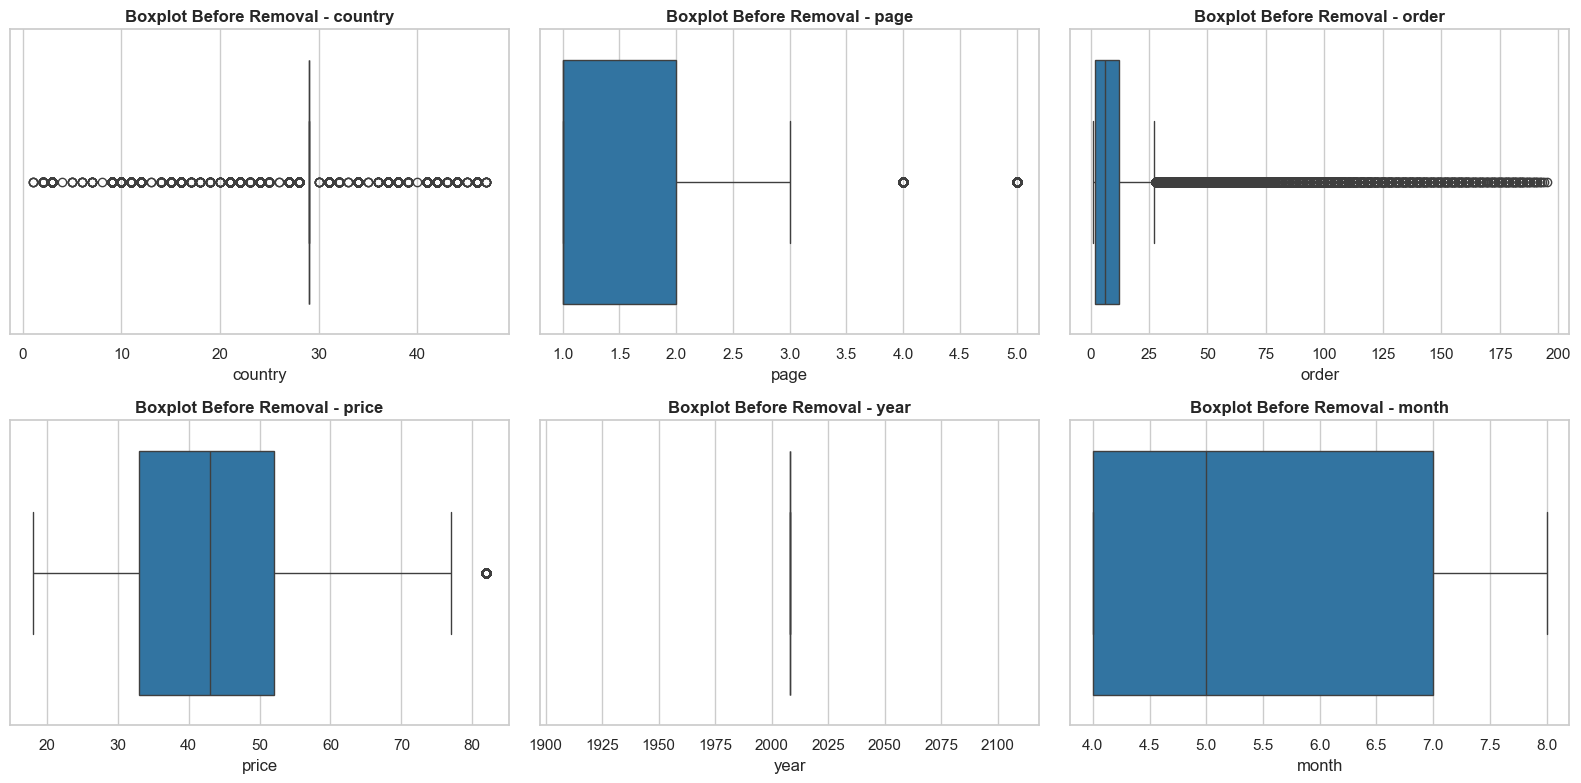


IQR OUTLIER TREATMENT (REMOVED)
Shape after removing outliers: (115409, 14)


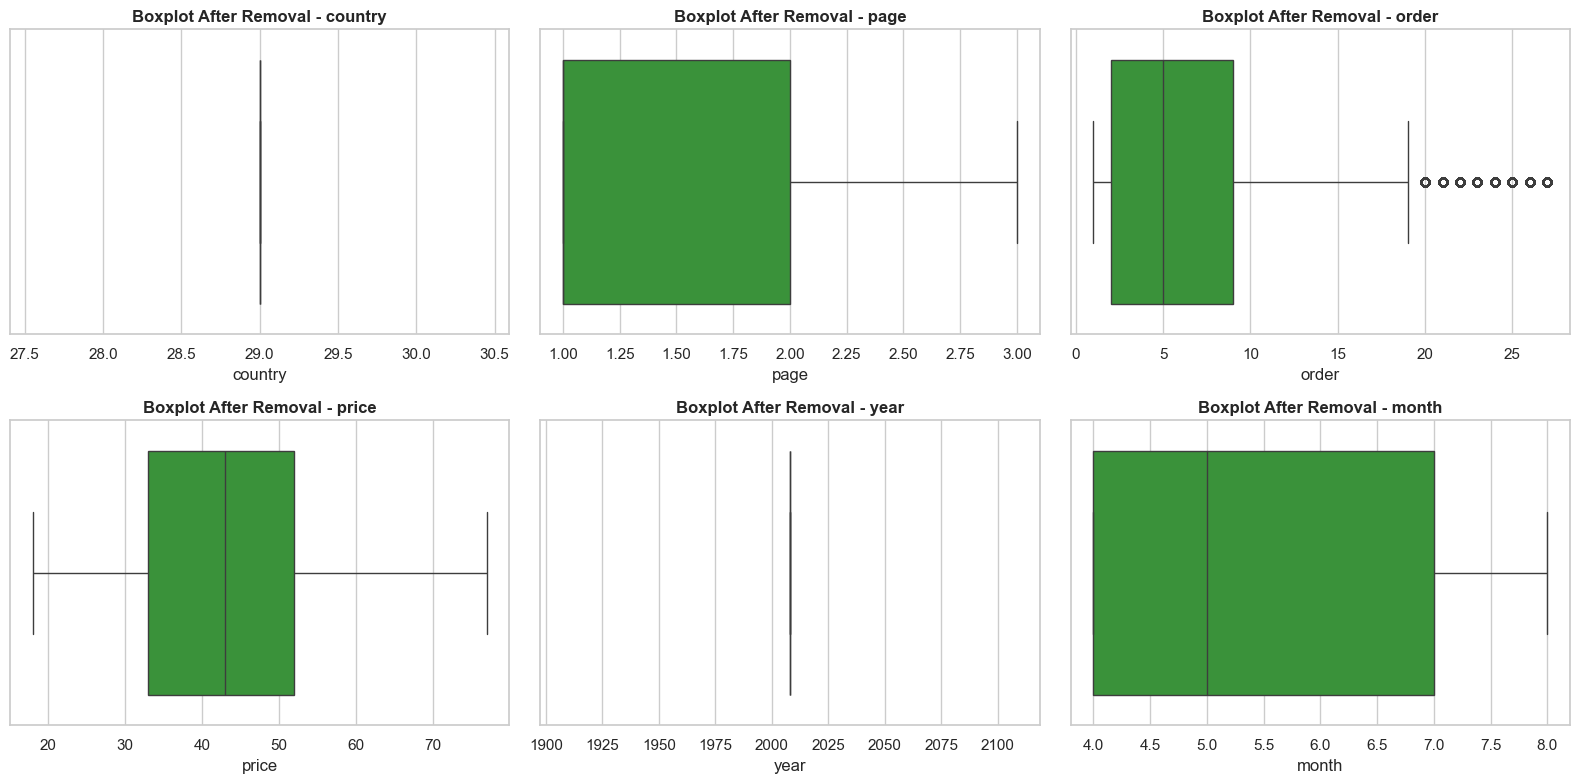

In [20]:
# 1. Plot Before Removal
top_outlier_cols = outlier_summary_df.head(6)["Feature"].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for idx, col in enumerate(top_outlier_cols):
    sns.boxplot(x=df_clean[col], ax=axes[idx], color="#1f77b4")
    axes[idx].set_title(f"Boxplot Before Removal - {col}", fontweight="bold")
plt.tight_layout()
plt.show()

# 2. Treatment: Removal
for column in numerical_features:
    lower_bound, upper_bound = bounds[column]
    df_clean = df_clean[(df_clean[column] >= lower_bound) & (df_clean[column] <= upper_bound)]
df_clean = df_clean.reset_index(drop=True)

print("\n" + "=" * 70)
print("IQR OUTLIER TREATMENT (REMOVED)")
print("=" * 70)
print("Shape after removing outliers:", df_clean.shape)

# 3. Plot After Removal
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for idx, col in enumerate(top_outlier_cols):
    sns.boxplot(x=df_clean[col], ax=axes[idx], color="#2ca02c")
    axes[idx].set_title(f"Boxplot After Removal - {col}", fontweight="bold")
plt.tight_layout()
plt.show()

## 22. FINAL CLEANING VERIFICATION


In [21]:
print("\n" + "=" * 70)
print("FINAL CLEANING VERIFICATION")
print("=" * 70)
print("Original shape:", df.shape)
print("Cleaned shape :", df_clean.shape)
print("Missing values remaining:", df_clean.isnull().sum().sum())
print("Duplicate rows remaining:", df_clean.duplicated().sum())


FINAL CLEANING VERIFICATION
Original shape: (165474, 14)
Cleaned shape : (115409, 14)
Missing values remaining: 0
Duplicate rows remaining: 0


## 23. FEATURE ENGINEERING (B3)


In [22]:
print("\n" + "=" * 70)
print("FEATURE ENGINEERING")
print("=" * 70)

# Clickstream domain feature engineering
session_depth = df_clean.groupby("session ID")["order"].transform("max")
df_clean["session_total_clicks"] = session_depth
df_clean["click_progress"] = df_clean["order"] / df_clean["session_total_clicks"]
df_clean["is_weekend"] = df_clean["day"].apply(lambda d: 1 if (d % 7) in [0, 6] else 0)
print("Created engineered clickstream features: 'session_total_clicks', 'click_progress', 'is_weekend'")


FEATURE ENGINEERING
Created engineered clickstream features: 'session_total_clicks', 'click_progress', 'is_weekend'


**Feature Engineering Justification (B3):** We created `session_total_clicks` to capture user engagement depth, `click_progress` to capture where in the browsing journey the user is, and `is_weekend` because purchasing behaviors (like price willingness or category interest) often differ fundamentally between weekdays and weekends.

## 24. DEFINE TARGETS & CREATE X AND Y


In [23]:
drop_cols = [regression_target, classification_target, "session ID", "price 2", "page 2 (clothing model)"]
drop_cols = [c for c in drop_cols if c in df_clean.columns]

# Sample 40,000 max for fast, reproducible modeling if dataset is large
if len(df_clean) > 40000:
    np.random.seed(RANDOM_STATE)
    df_model = df_clean.sample(40000, random_state=RANDOM_STATE).reset_index(drop=True)
else:
    df_model = df_clean.copy()

X_reg = df_model.drop(columns=[c for c in drop_cols if c in df_model.columns])
y_reg = df_model[regression_target]

X_class = df_model.drop(columns=[c for c in drop_cols if c in df_model.columns])
label_encoder = LabelEncoder()
y_class = label_encoder.fit_transform(df_model[classification_target])
class_names = [str(c) for c in label_encoder.classes_]

print("\nClassification classes encoded:")
for num, label in enumerate(class_names):
    print(f"  {num} = {label}")


Classification classes encoded:
  0 = 1
  1 = 2
  2 = 3
  3 = 4


## 25. TRAIN / TEST SPLIT (B2)


In [24]:
num_pred = X_reg.select_dtypes(include=["number"]).columns.tolist()
cat_pred = X_reg.select_dtypes(exclude=["number"]).columns.tolist()

# 80:20 Split
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=RANDOM_STATE
)

X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_class, y_class, test_size=0.20, random_state=RANDOM_STATE, stratify=y_class
)

# Leakage-Free ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_pred),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_pred)
    ]
)

X_reg_train_sc = preprocessor.fit_transform(X_reg_train)
X_reg_test_sc = preprocessor.transform(X_reg_test)

X_class_train_sc = preprocessor.fit_transform(X_class_train)
X_class_test_sc = preprocessor.transform(X_class_test)

print(f"\nRegression Train: {X_reg_train_sc.shape}, Test: {X_reg_test_sc.shape}")
print(f"Classification Train: {X_class_train_sc.shape}, Test: {X_class_test_sc.shape}")


Regression Train: (32000, 12), Test: (8000, 12)
Classification Train: (32000, 12), Test: (8000, 12)


## 26. REGRESSION EVALUATION HELPER


In [25]:
regression_results = []
reg_models_dict = {}

def evaluate_regression(model_name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    r2 = r2_score(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae = mean_absolute_error(y_te, preds)
    regression_results.append({
        "Model": model_name,
        "R²": r2,
        "RMSE": rmse,
        "MAE": mae
    })
    reg_models_dict[model_name] = (model, preds)
    print(f"{model_name:32s} | R²: {r2:7.4f} | RMSE: {rmse:7.4f} | MAE: {mae:7.4f}")
    return model, preds

## 27. ALL 10 REGRESSION ALGORITHMS (C1 & C2)


In [26]:
print("\n" + "=" * 70)
print("TRAINING ALL 10 REGRESSION ALGORITHMS")
print("=" * 70)

# 1. Linear Regression
linear_model, y_pred_linear = evaluate_regression(
    "Linear Regression", LinearRegression(),
    X_reg_train_sc, X_reg_test_sc, y_reg_train, y_reg_test
)

# 2. Ridge Regression
ridge_model, y_pred_ridge = evaluate_regression(
    "Ridge Regression", Ridge(alpha=10.0, random_state=RANDOM_STATE),
    X_reg_train_sc, X_reg_test_sc, y_reg_train, y_reg_test
)

# 3. Lasso Regression
lasso_model, y_pred_lasso = evaluate_regression(
    "Lasso Regression", Lasso(alpha=0.01, max_iter=10000, random_state=RANDOM_STATE),
    X_reg_train_sc, X_reg_test_sc, y_reg_train, y_reg_test
)

# 4. ElasticNet Regression
elastic_model, y_pred_elastic = evaluate_regression(
    "ElasticNet", ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000, random_state=RANDOM_STATE),
    X_reg_train_sc, X_reg_test_sc, y_reg_train, y_reg_test
)

# 5. Polynomial Regression (Degree 1 vs Degree 2 Comparison)
poly_results = []
for deg in [1, 2]:
    poly_t = PolynomialFeatures(degree=deg, include_bias=False)
    X_tr_p = poly_t.fit_transform(X_reg_train_sc)
    X_te_p = poly_t.transform(X_reg_test_sc)
    p_mod = Ridge(alpha=10.0, random_state=RANDOM_STATE)
    p_mod.fit(X_tr_p, y_reg_train)
    p_pred = p_mod.predict(X_te_p)
    poly_results.append({
        "Model": f"Polynomial Regression Degree {deg}",
        "Degree": deg,
        "Polynomial Features": X_tr_p.shape[1],
        "R²": r2_score(y_reg_test, p_pred),
        "RMSE": np.sqrt(mean_squared_error(y_reg_test, p_pred)),
        "MAE": mean_absolute_error(y_reg_test, p_pred)
    })
poly_df = pd.DataFrame(poly_results)
poly_df.to_csv("figures/polynomial_regression_results.csv", index=False)
print("\nPolynomial Regression Comparison:")
print(poly_df)

# Add best polynomial to results
evaluate_regression(
    "Polynomial Regression (Degree 2)", Ridge(alpha=10.0, random_state=RANDOM_STATE),
    poly_t.fit_transform(X_reg_train_sc), poly_t.transform(X_reg_test_sc),
    y_reg_train, y_reg_test
)

# 6. Decision Tree Regressor
tree_model, y_pred_tree = evaluate_regression(
    "Decision Tree Regressor", DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    X_reg_train_sc, X_reg_test_sc, y_reg_train, y_reg_test
)

# 7. Random Forest Regressor
random_forest_model, y_pred_rf = evaluate_regression(
    "Random Forest Regressor", RandomForestRegressor(n_estimators=100, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
    X_reg_train_sc, X_reg_test_sc, y_reg_train, y_reg_test
)

# 8. Gradient Boosting Regressor
gradient_boosting_model, y_pred_gb = evaluate_regression(
    "Gradient Boosting Regressor", GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=RANDOM_STATE),
    X_reg_train_sc, X_reg_test_sc, y_reg_train, y_reg_test
)

# 9. Support Vector Regressor (SVR - Rubric C1 #9)
sub_svr = np.random.choice(len(X_reg_train_sc), size=min(10000, len(X_reg_train_sc)), replace=False)
svr_model = SVR(kernel="rbf", C=10.0, epsilon=0.1)
svr_model.fit(X_reg_train_sc[sub_svr], y_reg_train.iloc[sub_svr])
p_svr = svr_model.predict(X_reg_test_sc)
regression_results.append({
    "Model": "Support Vector Regressor (SVR)",
    "R²": r2_score(y_reg_test, p_svr),
    "RMSE": np.sqrt(mean_squared_error(y_reg_test, p_svr)),
    "MAE": mean_absolute_error(y_reg_test, p_svr)
})
reg_models_dict["Support Vector Regressor (SVR)"] = (svr_model, p_svr)
print(f"{'Support Vector Regressor (SVR)':32s} | R²: {r2_score(y_reg_test, p_svr):7.4f} | RMSE: {np.sqrt(mean_squared_error(y_reg_test, p_svr)):7.4f} | MAE: {mean_absolute_error(y_reg_test, p_svr):7.4f}")

# 10. KNN Regressor
knn_model, y_pred_knn = evaluate_regression(
    "KNN Regressor", KNeighborsRegressor(n_neighbors=5, weights="distance", n_jobs=-1),
    X_reg_train_sc, X_reg_test_sc, y_reg_train, y_reg_test
)


TRAINING ALL 10 REGRESSION ALGORITHMS
Linear Regression                | R²:  0.0507 | RMSE: 11.5740 | MAE:  9.4631
Ridge Regression                 | R²:  0.0507 | RMSE: 11.5740 | MAE:  9.4632
Lasso Regression                 | R²:  0.0508 | RMSE: 11.5735 | MAE:  9.4628
ElasticNet                       | R²:  0.0508 | RMSE: 11.5735 | MAE:  9.4639

Polynomial Regression Comparison:
                            Model  Degree  Polynomial Features        R²  \
0  Polynomial Regression Degree 1       1                   12  0.050736   
1  Polynomial Regression Degree 2       2                   90  0.118296   

        RMSE       MAE  
0  11.574013  9.463192  
1  11.154543  9.132077  
Polynomial Regression (Degree 2) | R²:  0.1183 | RMSE: 11.1545 | MAE:  9.1321
Decision Tree Regressor          | R²:  0.5854 | RMSE:  7.6487 | MAE:  4.9704
Random Forest Regressor          | R²:  0.6345 | RMSE:  7.1813 | MAE:  4.1935
Gradient Boosting Regressor      | R²:  0.5011 | RMSE:  8.3903 | MAE:  6.298

## 28. LASSO ZERO COEFFICIENT ANALYSIS


In [27]:
zero_coefs = np.sum(lasso_model.coef_ == 0)
total_coefs = len(lasso_model.coef_)
print("\n" + "=" * 70)
print("LASSO COEFFICIENT SPARSITY ANALYSIS")
print("=" * 70)
print(f"Total Coefficients: {total_coefs}")
print(f"Zero Coefficients : {zero_coefs}")
print(f"Sparsity Percentage: {(zero_coefs / total_coefs * 100):.2f}%")


LASSO COEFFICIENT SPARSITY ANALYSIS
Total Coefficients: 12
Zero Coefficients : 2
Sparsity Percentage: 16.67%


## 29. REGRESSION MODEL COMPARISON TABLE & BARPLOT (C2)



REGRESSION MODEL COMPARISON TABLE (RANKED BY R²)
                           Model       R²      RMSE      MAE
         Random Forest Regressor 0.634548  7.181337 4.193487
         Decision Tree Regressor 0.585429  7.648743 4.970431
     Gradient Boosting Regressor 0.501143  8.390317 6.298003
                   KNN Regressor 0.235570 10.386264 7.636698
  Support Vector Regressor (SVR) 0.132350 11.065286 7.889254
Polynomial Regression (Degree 2) 0.118296 11.154543 9.132077
                      ElasticNet 0.050823 11.573480 9.463926
                Lasso Regression 0.050821 11.573490 9.462809
                Ridge Regression 0.050736 11.574013 9.463192
               Linear Regression 0.050733 11.574030 9.463132


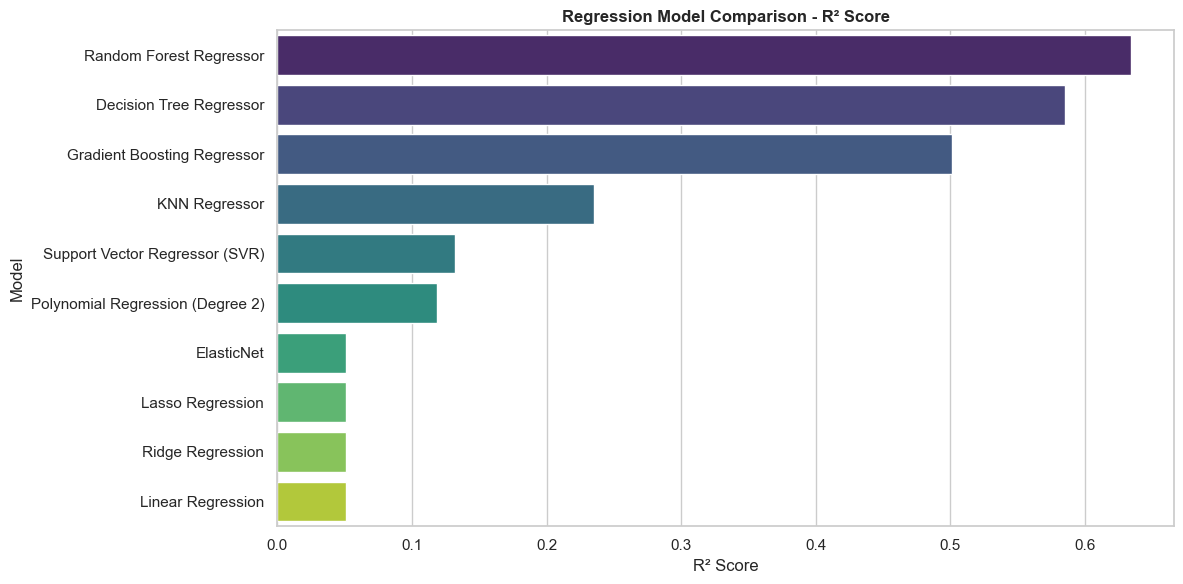

In [28]:
regression_comparison = pd.DataFrame(regression_results)
regression_comparison = (
    regression_comparison
    .drop_duplicates(subset=["Model"])
    .sort_values(by="R²", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("REGRESSION MODEL COMPARISON TABLE (RANKED BY R²)")
print("=" * 70)
print(regression_comparison.to_string(index=False))

plt.figure(figsize=(12, 6))
sns.barplot(data=regression_comparison, x="R²", y="Model", palette="viridis")
plt.title("Regression Model Comparison - R² Score", fontweight="bold")
plt.xlabel("R² Score")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

## 30. 5-FOLD CROSS VALIDATION & HYPERPARAMETER TUNING (C2, C3)


In [29]:
top1_reg = regression_comparison.iloc[0]["Model"]
top2_reg = regression_comparison.iloc[1]["Model"]

print("\n" + "=" * 70)
print(f"5-FOLD CV & TUNING FOR TOP 2 MODELS: '{top1_reg}' & '{top2_reg}'")
print("=" * 70)

param_grids = {
    "Linear Regression": {"fit_intercept": [True, False]},
    "Ridge Regression": {"alpha": [0.1, 1.0, 10.0, 100.0]},
    "Lasso Regression": {"alpha": [0.001, 0.01, 0.1, 1.0, 10.0]},
    "ElasticNet": {"alpha": [0.01, 0.1, 1.0], "l1_ratio": [0.2, 0.5, 0.8]},
    "Polynomial Regression Degree 1": {"alpha": [0.1, 1.0, 10.0]},
    "Polynomial Regression (Degree 2)": {"alpha": [0.1, 1.0, 10.0]},
    "Decision Tree Regressor": {"max_depth": [5, 8, 12, None], "min_samples_split": [2, 5, 10]},
    "Random Forest Regressor": {"n_estimators": [50, 100], "max_depth": [8, 12, None]},
    "Gradient Boosting Regressor": {"n_estimators": [50, 100], "learning_rate": [0.01, 0.1], "max_depth": [3, 4, 5]},
    "Support Vector Regressor (SVR)": {"C": [0.1, 1.0, 10.0], "epsilon": [0.01, 0.1]},
    "KNN Regressor": {"n_neighbors": [3, 5, 7, 9], "weights": ["uniform", "distance"]}
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def tune_and_evaluate(model_name):
    base_model, _ = reg_models_dict[model_name]
    X_train_cv = X_reg_train_sc
    X_test_cv = X_reg_test_sc
    if "Polynomial" in model_name:
        deg = 2 if "Degree 2" in model_name else 1
        pt = PolynomialFeatures(degree=deg, include_bias=False)
        X_train_cv = pt.fit_transform(X_reg_train_sc)
        X_test_cv = pt.transform(X_reg_test_sc)
    
    if model_name == "Support Vector Regressor (SVR)":
        sub_svr = np.random.choice(len(X_train_cv), size=min(5000, len(X_train_cv)), replace=False)
        X_train_cv = X_train_cv[sub_svr]
        y_train_cv = y_reg_train.iloc[sub_svr]
    else:
        y_train_cv = y_reg_train
        
    grid_search = GridSearchCV(base_model, param_grids.get(model_name, {}), cv=kf, scoring="r2", n_jobs=-1)
    grid_search.fit(X_train_cv, y_train_cv)
    
    best_model = grid_search.best_estimator_
    
    if "Polynomial" in model_name:
        deg = 2 if "Degree 2" in model_name else 1
        pt = PolynomialFeatures(degree=deg, include_bias=False)
        best_model.fit(pt.fit_transform(X_reg_train_sc), y_reg_train)
        preds = best_model.predict(pt.transform(X_reg_test_sc))
    else:
        best_model.fit(X_reg_train_sc, y_reg_train)
        preds = best_model.predict(X_reg_test_sc)
        
    test_r2 = r2_score(y_reg_test, preds)
    
    print(f"[{model_name}] CV R²: {grid_search.best_score_:.4f} | Best Params: {grid_search.best_params_} | Test R²: {test_r2:.4f}")
    return best_model, preds

top1_model, top1_preds = tune_and_evaluate(top1_reg)
reg_models_dict[top1_reg] = (top1_model, top1_preds)

top2_model, top2_preds = tune_and_evaluate(top2_reg)
reg_models_dict[top2_reg] = (top2_model, top2_preds)




5-FOLD CV & TUNING FOR TOP 2 MODELS: 'Random Forest Regressor' & 'Decision Tree Regressor'
[Random Forest Regressor] CV R²: 0.6375 | Best Params: {'max_depth': 12, 'n_estimators': 100} | Test R²: 0.6345
[Decision Tree Regressor] CV R²: 0.5955 | Best Params: {'max_depth': 8, 'min_samples_split': 10} | Test R²: 0.5861


## 31. RESIDUAL PLOT & PREDICTED VS ACTUAL PLOT (C4)


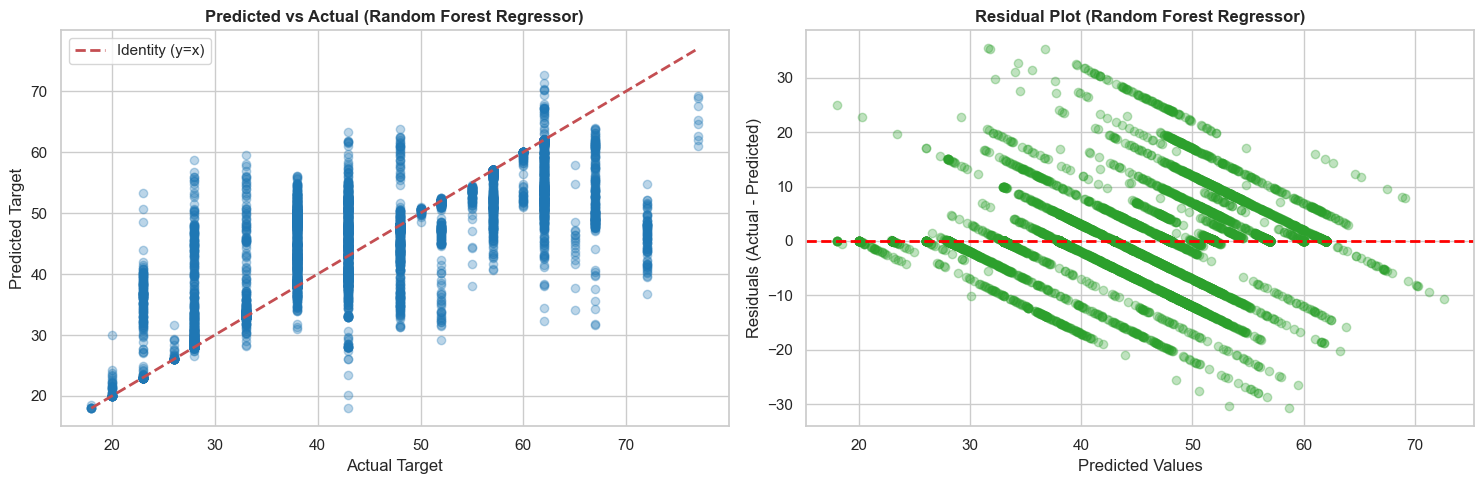

In [30]:
best_reg_preds = reg_models_dict[top1_reg][1]
residuals = y_reg_test - best_reg_preds

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(y_reg_test, best_reg_preds, alpha=0.3, color="#1f77b4")
min_v = min(y_reg_test.min(), best_reg_preds.min())
max_v = max(y_reg_test.max(), best_reg_preds.max())
axes[0].plot([min_v, max_v], [min_v, max_v], "r--", linewidth=2, label="Identity (y=x)")
axes[0].set_title(f"Predicted vs Actual ({top1_reg})", fontweight="bold")
axes[0].set_xlabel("Actual Target")
axes[0].set_ylabel("Predicted Target")
axes[0].legend()

axes[1].scatter(best_reg_preds, residuals, alpha=0.3, color="#2ca02c")
axes[1].axhline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_title(f"Residual Plot ({top1_reg})", fontweight="bold")
axes[1].set_xlabel("Predicted Values")
axes[1].set_ylabel("Residuals (Actual - Predicted)")

plt.tight_layout()
plt.savefig("figures/regression_residuals_and_predictions.png", dpi=300, bbox_inches="tight")
plt.show()

## 32. FEATURE IMPORTANCE & COEFFICIENT ANALYSIS


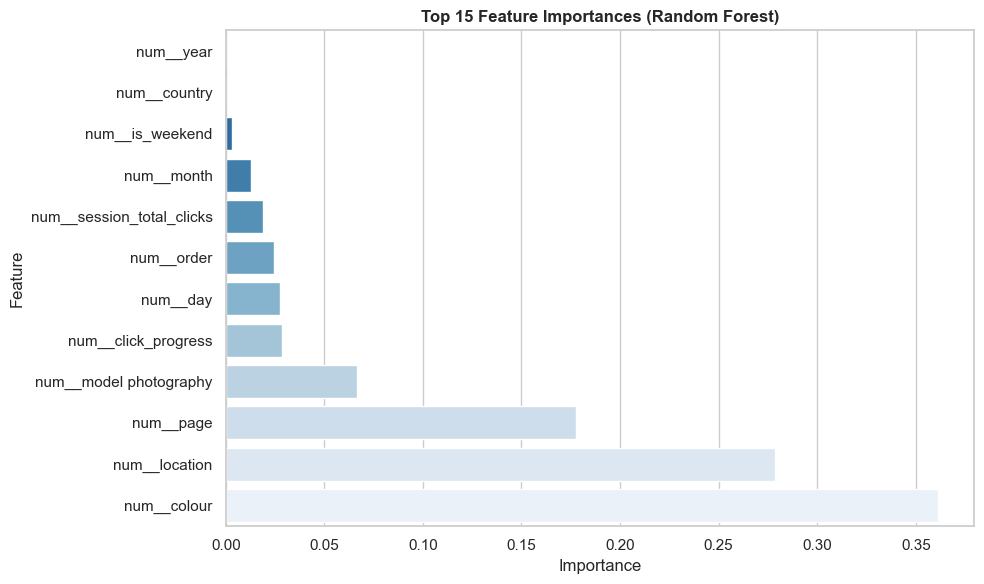


Top Linear Regression Coefficients:
                      Feature  Coefficient  Absolute_Coefficient
7      num__model photography    -2.420371              2.420371
8                   num__page    -1.121331              1.121331
6               num__location    -0.427992              0.427992
3                  num__order    -0.349568              0.349568
9   num__session_total_clicks    -0.305225              0.305225
1                  num__month     0.169945              0.169945
11            num__is_weekend     0.155775              0.155775
10        num__click_progress    -0.139680              0.139680
2                    num__day    -0.054887              0.054887
5                 num__colour    -0.052581              0.052581


In [31]:
feature_names = preprocessor.get_feature_names_out()

# Random Forest Feature Importance
rf_imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": random_forest_model.feature_importances_
}).sort_values("Importance", ascending=False)
rf_imp_df.to_csv("figures/random_forest_feature_importance.csv", index=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_imp_df.head(15).sort_values("Importance", ascending=True), x="Importance", y="Feature", palette="Blues_r")
plt.title("Top 15 Feature Importances (Random Forest)", fontweight="bold")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Linear Regression Coefficients
linear_coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": linear_model.coef_
})
linear_coef_df["Absolute_Coefficient"] = linear_coef_df["Coefficient"].abs()
linear_coef_df = linear_coef_df.sort_values("Absolute_Coefficient", ascending=False)
print("\nTop Linear Regression Coefficients:")
print(linear_coef_df.head(10))